# Week 4: Supervised Learning and Machine Learning Algorithms

## Learning Objectives

1. Learn about Supervised Learning (training ML models on labeled data, where we know the correct answers, to make predictions on new, unseen data)
2. Properly split data into training and testing sets
3. Multiple classification algorithms and when to use each
4. Evaluate model performance with appropriate metrics
5. Compare different models to find the best one

In [ ]:
import pandas as pd

df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.drop(columns=['time'], inplace=True)
df_features = df.iloc[:, :-1]
df_target = df['DEATH_EVENT']

X = df_features
y = df_target

## Train and test sets

We should divide the dataset to train and test splits. We train our ML algorithms on train dataset and evaluate their performance on test set.

## Why split data?

A critical principle in ML is avoiding data leakage. If we train and test on the same data, a model can simply memorize the training data instead of learning generalizable patterns. This leads to overly optimistic performance metrics.

Solution: Split data into:
- Training set (70%): Used to train the model
- Test set (30%): Used to evaluate performance on unseen data

Stratification: We use `stratify=y` to maintain the same class distribution (proportion of death events) in both train and test sets. This is important for imbalanced datasets.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=21)

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print('y_train: ', y_train.value_counts(normalize=True))
print('y_test: ', y_test.value_counts(normalize=True))

A model with random guess which always predict the majority group has 68% accuracy. 

## Normalize train and test sets separately

### Why normalize data?

Our features have different scales:
- Age: 40-80 years
- Ejection Fraction: 15-80%
- Platelets: 25,000-850,000 cells/μL

Algorithms like SVM and KNN are distance-based (calculating distances between data points). Large-scale features, like platelets, would dominate the distance calculation, making small-scale features, like ejection fraction, irrelevant.

Z-score Normalization: Transform each feature to have mean=0 and standard deviation=1, putting all of them on the same scale

Important: We normalize training and test sets separately to avoid data leakage. We shouldn't use test data statistics to transform the training data.

In [ ]:
from scipy.stats import zscore
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_train = zscore(X_train)
X_test = zscore(X_test)

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=100)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))

## Support Vector Machines (SVM)

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel='linear')
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))

## Exercise: Run SVM with RBF (Radial Basic Function) kernel and report metrics

In [ ]:
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))

## K-Nearest Neighbor (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))

## Baseline Model: Dummy Classifier

### What is a Baseline Model?

A baseline model is a simple, often trivial model used as a reference point to evaluate the performance of more complex ML models.

Why is it important?
- Provide a minimum performance threshold: Any real model should beat the baseline
- Help detect overfitting: If your fancy model barely beats the baseline, something is wrong
- Establish expectations (show what luck alone can achieve)
- Useful for imbalanced datasets (reveal class distribution bias)
- Sanity check: If you can't beat the baseline, reconsider your approach

Our baseline: If we just always guess "survived" (the majority class), we would get an accuracy of 67.8% (proportion of class 0 in test set).

This means any real ML model must get > 67.8% accuracy to be useful.

### Dummy Classifier Strategies

DummyClassifier provides different simple strategies:

| Strategy | What it does | Use Case |
|----------|-------------|----------|
| most_frequent | Always predict the most common class | Baseline for imbalanced data |
| stratified | Predict randomly but matches class distribution | Compare to random guessing |
| uniform | Completely random predictions | See what true random guessing gives |
| constant | Always predict the same class you specify | Custom baseline |

For our dataset:
- most_frequent strategy: Always predict "survived" (class 0) → ~67.8% accuracy
- stratified strategy: Randomly guesses with 67.8% "survived" and 32.2% "death" → accuracy varies
- uniform strategy: 50/50 random guess → ~50% accuracy (worse than most_frequent!)

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)

preds = dummy_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))

## Exercise: Design another classifier not mentioned above

In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))

## Exercise

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM (RBF)': CalibratedClassifierCV(SVC(kernel='rbf'), ensemble=False),
    'SVM (Linear)': CalibratedClassifierCV(SVC(kernel='linear'), ensemble=False),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Dummy (Baseline)': DummyClassifier(strategy='most_frequent')
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds

    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1-Score': f1_score(y_test, preds, zero_division=0)
    }

results_df = pd.DataFrame(results).T
print(f"\n{"-" * 70}")
print("Model Performance Comparison")
print(f"{"-" * 70}")
print(results_df.round(4))


### Visualization 1: Metrics Comparison Bar Chart

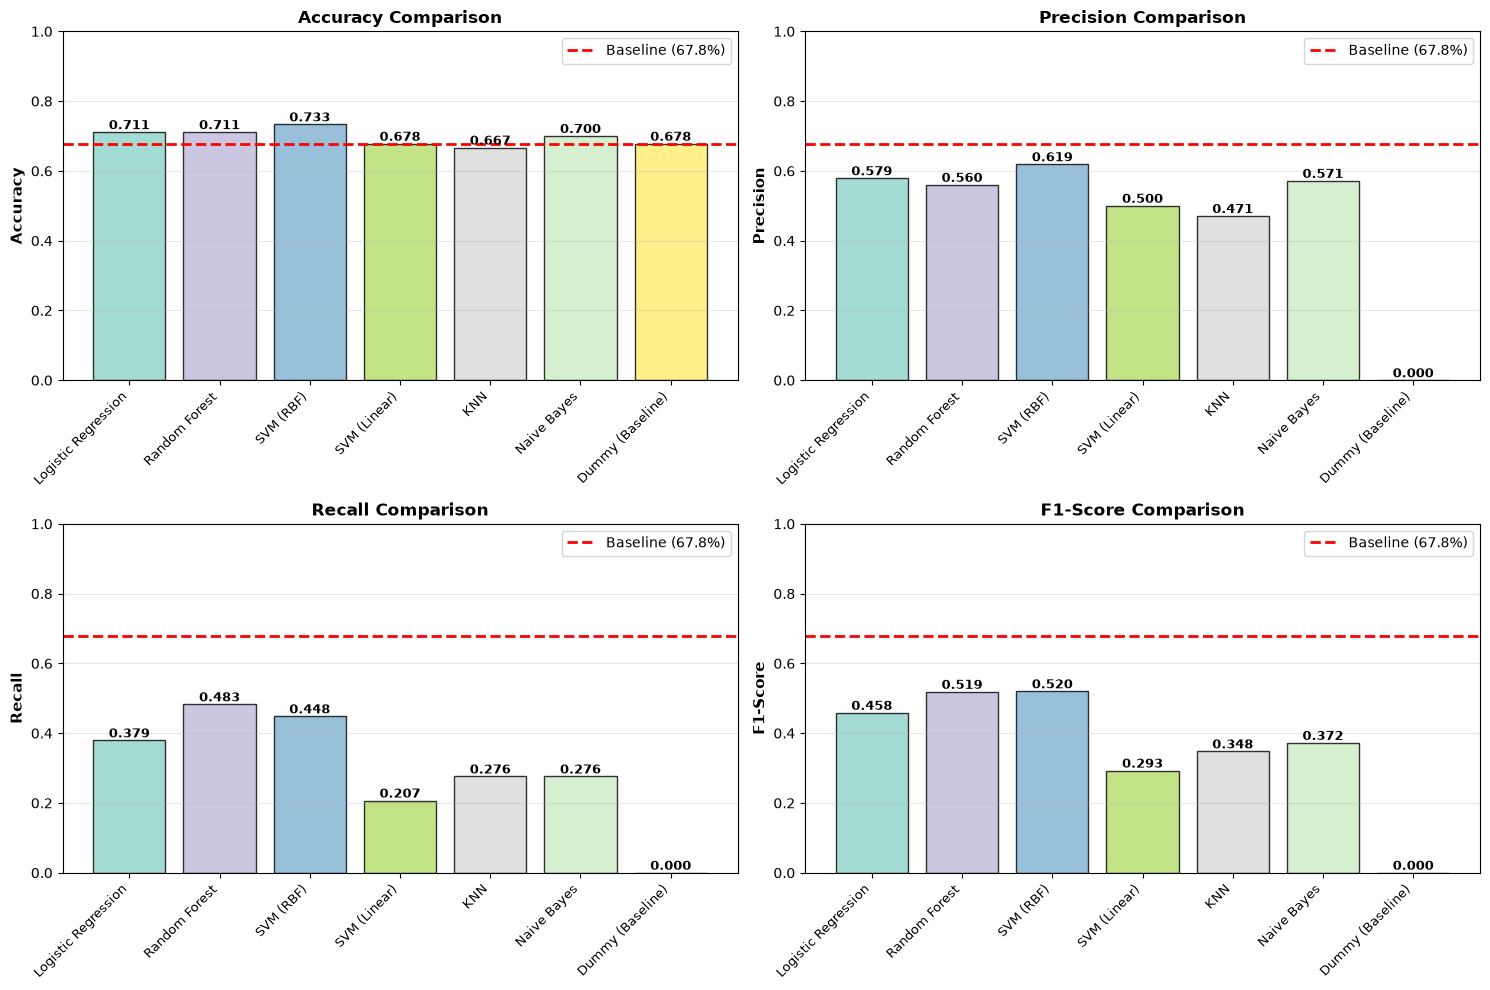

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = plt.cm.Set3(np.linspace(0, 1, len(models)))

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = results_df[metric].values
    x_pos = np.arange(len(models))

    bars = ax.bar(x_pos, values, color=colors, alpha=0.8, edgecolor='black')

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.axhline(y=0.678, color='red', linestyle='--', linewidth=2, label='Baseline (67.8%)')
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models.keys(), rotation=45, ha='right', fontsize=9)
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print(f"Best Accuracy: {results_df['Accuracy'].idxmax()} ({results_df['Accuracy'].max():.4f})")
print(f"Best Precision: {results_df['Precision'].idxmax()} ({results_df['Precision'].max():.4f})")
print(f"Best Recall: {results_df['Recall'].idxmax()} ({results_df['Recall'].max():.4f})")
print(f"Best F1-Score: {results_df['F1-Score'].idxmax()} ({results_df['F1-Score'].max():.4f})")

### Visualization 2: Confusion Matrices for Key Models

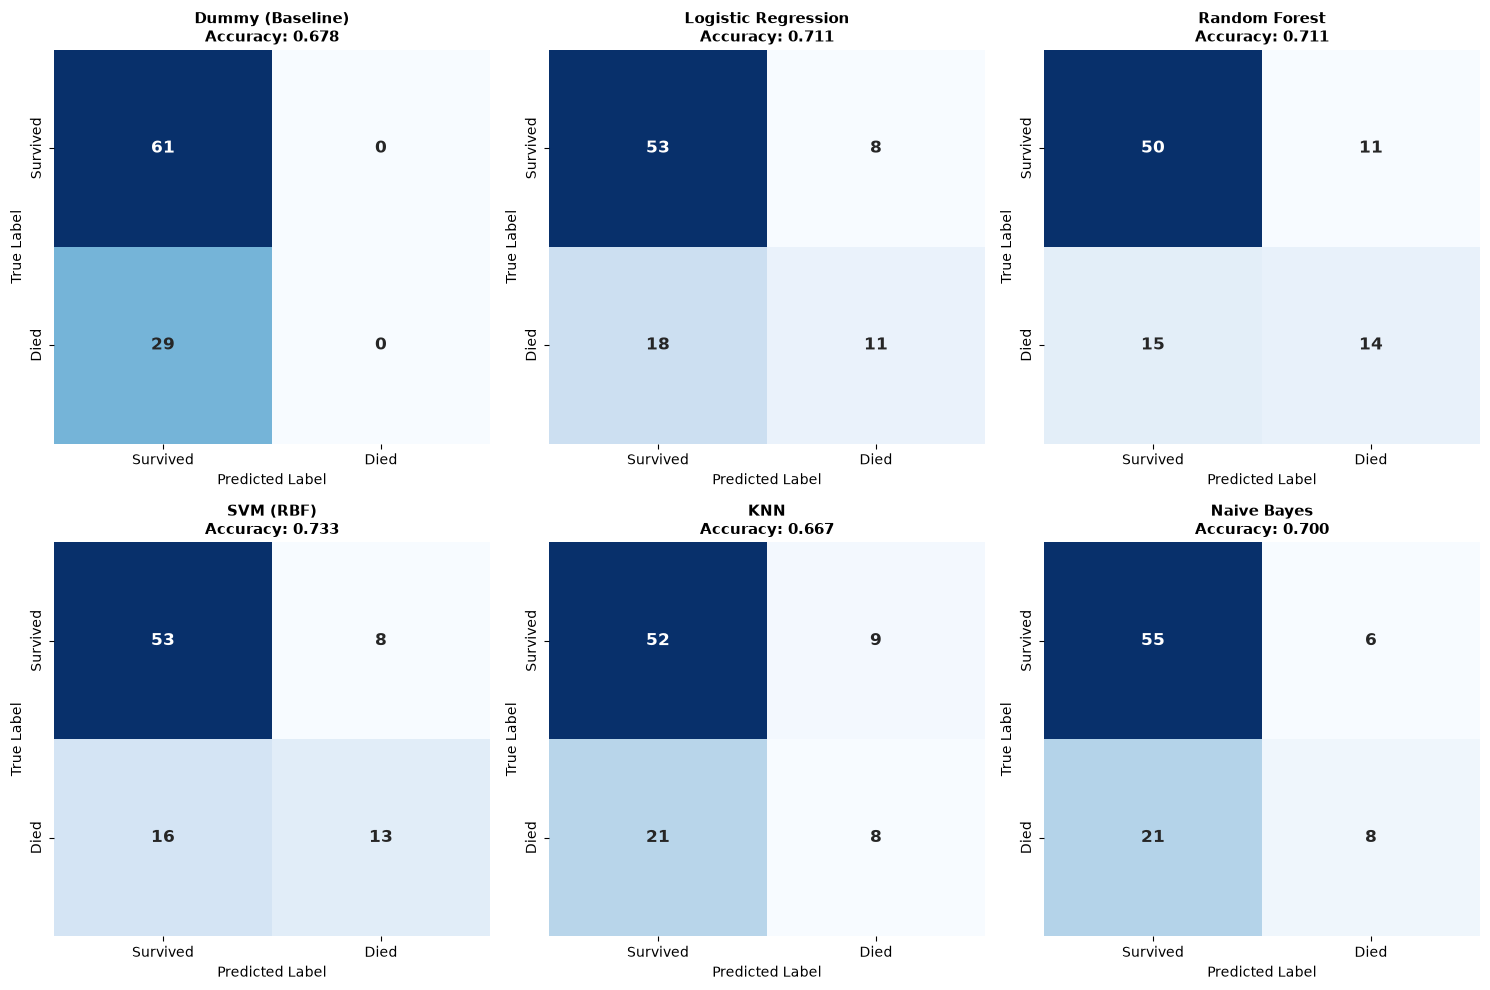


------------------------------------------------------------
Confusion Matrix Interpretation
------------------------------------------------------------

Dummy (Baseline)
  True Negatives (Survived correctly): 61
  False Positives (Survived but predicted Died): 0
  False Negatives (Died but predicted Survived): 29
  True Positives (Died correctly): 0

Logistic Regression
  True Negatives (Survived correctly): 53
  False Positives (Survived but predicted Died): 8
  False Negatives (Died but predicted Survived): 18
  True Positives (Died correctly): 11

Random Forest
  True Negatives (Survived correctly): 50
  False Positives (Survived but predicted Died): 11
  False Negatives (Died but predicted Survived): 15
  True Positives (Died correctly): 14

SVM (RBF)
  True Negatives (Survived correctly): 53
  False Positives (Survived but predicted Died): 8
  False Negatives (Died but predicted Survived): 16
  True Positives (Died correctly): 13

KNN
  True Negatives (Survived correctly): 52
 

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

key_models = ['Dummy (Baseline)', 'Logistic Regression', 'Random Forest', 
              'SVM (RBF)', 'KNN', 'Naive Bayes']

for idx, model_name in enumerate(key_models):
    cm = confusion_matrix(y_test, predictions[model_name])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar=False, annot_kws={'fontsize': 12, 'fontweight': 'bold'})

    axes[idx].set_title(f'{model_name}\nAccuracy: {results[model_name]["Accuracy"]:.3f}',
                        fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].set_xticklabels(['Survived', 'Died'])
    axes[idx].set_yticklabels(['Survived', 'Died'])

plt.tight_layout()
plt.show()

print(f"\n{"-" * 60}")
print("Confusion Matrix Interpretation")
print(f"{"-" * 60}")
for model_name in key_models:
    cm = confusion_matrix(y_test, predictions[model_name])
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{model_name}")
    print(f"  True Negatives (Survived correctly): {tn}")
    print(f"  False Positives (Survived but predicted Died): {fp}")
    print(f"  False Negatives (Died but predicted Survived): {fn}")
    print(f"  True Positives (Died correctly): {tp}")

### Visualization 3: ROC Curves for Model Comparison

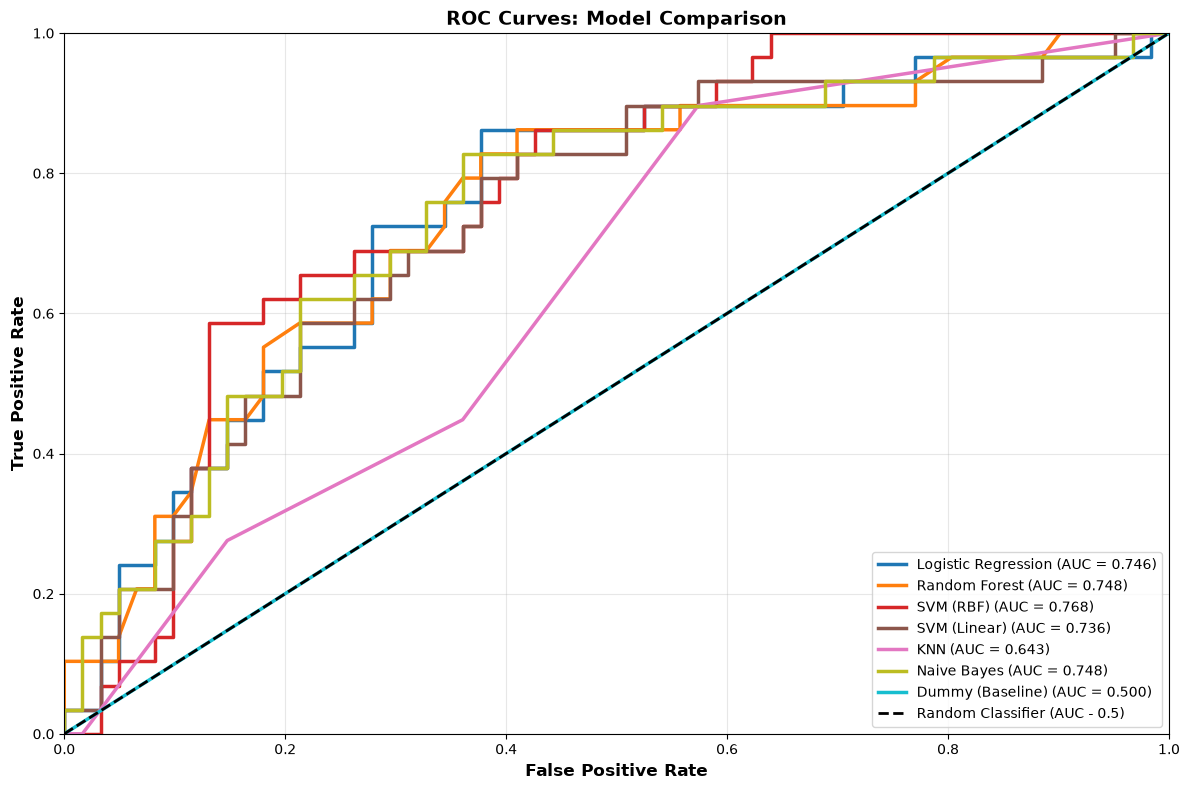


--------------------------------------------------
ROC-AUC Scores
--------------------------------------------------
Logistic Regression       AUC-ROC: 0.7462
Random Forest             AUC-ROC: 0.7479
SVM (RBF)                 AUC-ROC: 0.7682
SVM (Linear)              AUC-ROC: 0.7360
KNN                       AUC-ROC: 0.6427
Naive Bayes               AUC-ROC: 0.7479
Dummy (Baseline)          AUC-ROC: 0.5000


In [24]:
fig, axes = plt.subplots(figsize=(12, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for (name, model), color in zip(models.items(), colors):
    model.fit(X_train, y_train)

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.predict(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    axes.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})',
              linewidth=2.5, color=color)

axes.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC - 0.5)')

axes.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes.set_title('ROC Curves: Model Comparison', fontsize=14, fontweight='bold')
axes.legend(loc='lower right', fontsize=10)
axes.grid(True, alpha=0.3)
axes.set_xlim([0, 1])
axes.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"\n{"-" * 50}")
print("ROC-AUC Scores")
print(f"{"-" * 50}")
for name, model in models.items():
    model.fit(X_train, y_train)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.predict_proba(X_test)
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"{name:25} AUC-ROC: {roc_auc:.4f}")

### Visualization 4: Feature Importance from Random Forest

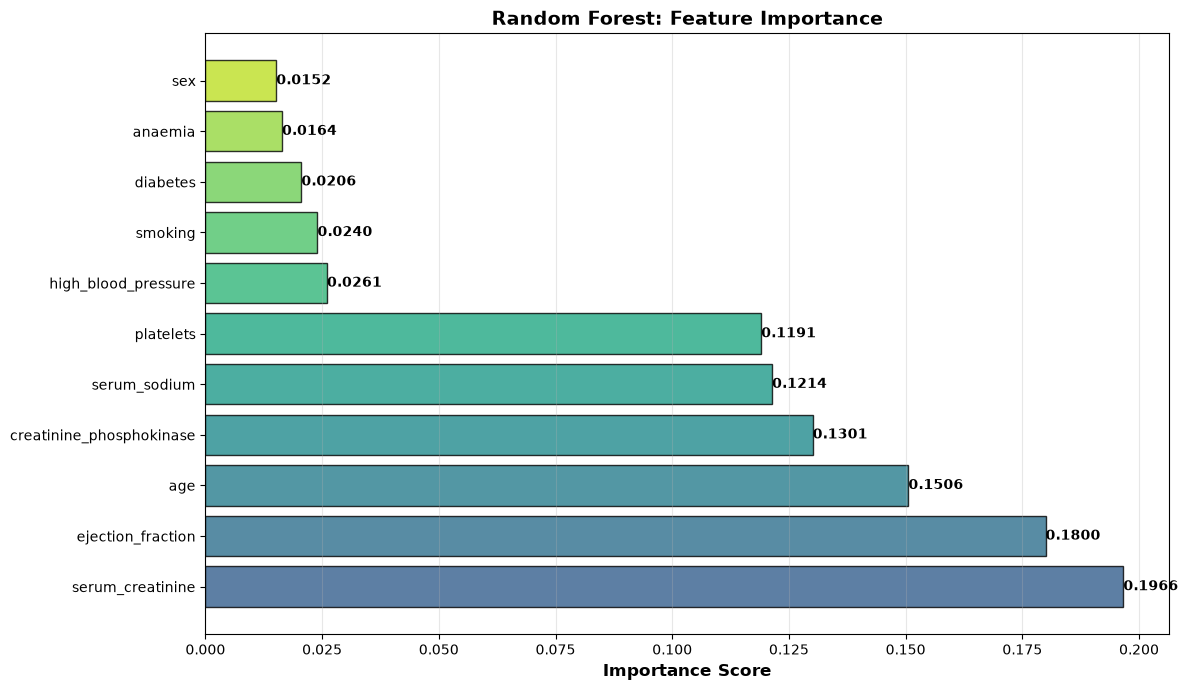


--------------------------------------------------
Feature Importance Ranking (Random Forest)
--------------------------------------------------
serum_creatinine               0.196649
ejection_fraction              0.179973
age                            0.150600
creatinine_phosphokinase       0.130091
serum_sodium                   0.121398
platelets                      0.119061
high_blood_pressure            0.026055
smoking                        0.024011
diabetes                       0.020561
anaemia                        0.016412
sex                            0.015190


In [27]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(figsize=(12, 7))

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_importance)))
bars = axes.barh(feature_importance['Feature'], feature_importance['Importance'],
                 color=colors, edgecolor='black', alpha=0.8)

for idx, bar in enumerate(bars):
    width = bar.get_width()
    axes.text(width, bar.get_y() + bar.get_height()/2.,
              f'{width:.4f}', ha='left', va='center', fontsize=10, fontweight='bold')

axes.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
axes.set_title('Random Forest: Feature Importance', fontsize=14, fontweight='bold')
axes.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{"-" * 50}")
print("Feature Importance Ranking (Random Forest)")
print(f"{"-" * 50}")
for idx, row in feature_importance.iterrows():
    print(f"{row['Feature']:30} {row['Importance']:.6f}")

### Visualization 5: Class Distribution & Data Split

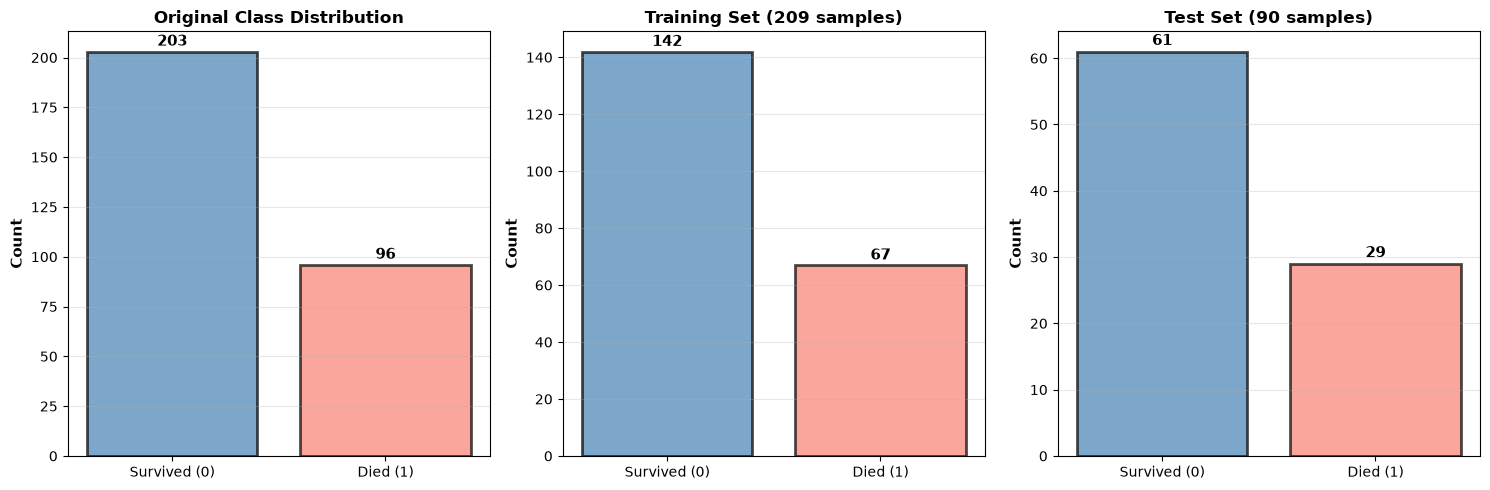


----------------------------------------
Dataset Statistics
----------------------------------------
Total samples: 299
Training samples: 209 (69.9%)
Test samples: 90 (30.1%)

Class Distribution (Survived:Died)
Overall: 203:96 (67.9%:32.1%)
Training: 142:67 (67.9%:32.1%)
Test: 61:29 (67.8%:32.2%)


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

original_dist = y.value_counts()
axes[0].bar(['Survived (0)', 'Died (1)'], original_dist.values,
            color=['steelblue', 'salmon'], alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[0].set_title('Original Class Distribution', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(original_dist.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold', fontsize=11)

train_dist = y_train.value_counts()
axes[1].bar(['Survived (0)', 'Died (1)'], train_dist.values,
            color=['steelblue', 'salmon'], alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1].set_title(f'Training Set ({len(y_train)} samples)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(train_dist.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=11)

test_dist = y_test.value_counts()
axes[2].bar(['Survived (0)', 'Died (1)'], test_dist.values,
            color=['steelblue', 'salmon'], alpha=0.7, edgecolor='black', linewidth=2)
axes[2].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[2].set_title(f'Test Set ({len(y_test)} samples)', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(test_dist.values):
    axes[2].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\n{"-" * 40}")
print("Dataset Statistics")
print(f"{"-" * 40}")
print(f"Total samples: {len(y)}")
print(f"Training samples: {len(y_train)} ({len(y_train)/len(y)*100:.1f}%)")
print(f"Test samples: {len(y_test)} ({len(y_test)/len(y)*100:.1f}%)")
print(f"\nClass Distribution (Survived:Died)")
print(f"Overall: {original_dist[0]}:{original_dist[1]} ({original_dist[0]/len(y)*100:.1f}%:{original_dist[1]/len(y)*100:.1f}%)")
print(f"Training: {train_dist[0]}:{train_dist[1]} ({train_dist[0]/len(y_train)*100:.1f}%:{train_dist[1]/len(y_train)*100:.1f}%)")
print(f"Test: {test_dist[0]}:{test_dist[1]} ({test_dist[0]/len(y_test)*100:.1f}%:{test_dist[1]/len(y_test)*100:.1f}%)")

### Visualization 6: Model Performance Heatmap

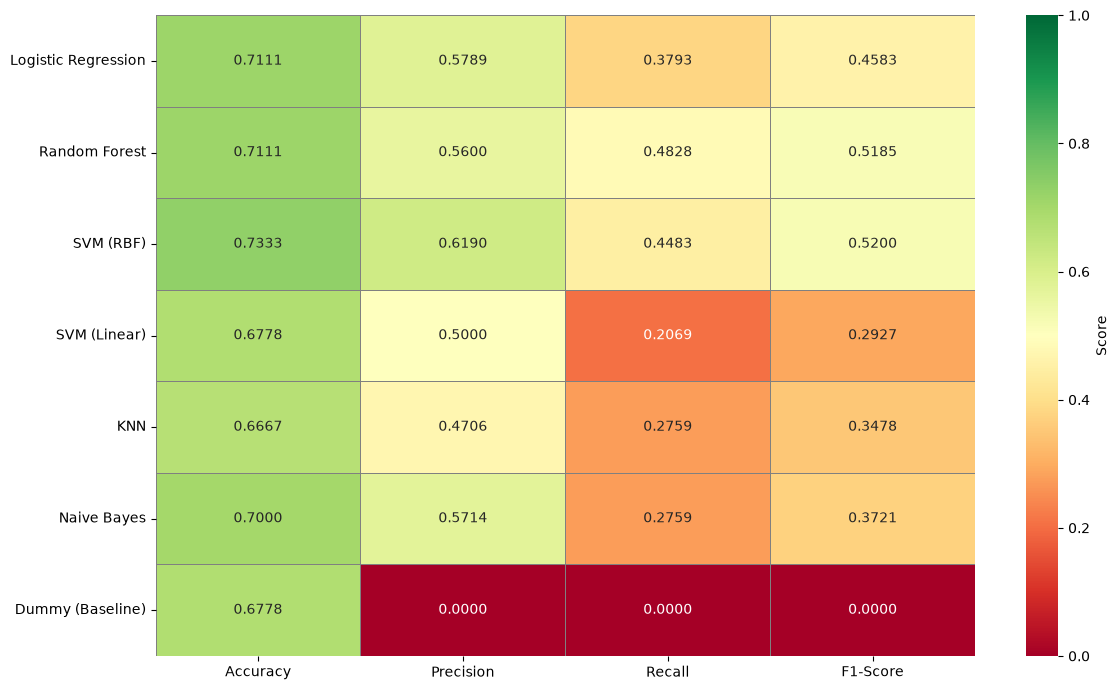

In [33]:
fig, axes = plt.subplots(figsize=(12, 7))

sns.heatmap(results_df, annot=True, fmt=".4f", cmap='RdYlGn', center=0.5,
            cbar_kws={'label': 'Score'}, linewidths=0.5, linecolor='gray',
            ax=axes, vmin=0, vmax=1)

plt.tight_layout()
plt.show()

## Model Selection Guide

### Choose your model based on your priority

1. Best overall (balanced performance)
    - Look for high F1-Score (balances precision & recall)

2. Minimize False Negatives (Critical)
    - Maximize Recall (catches all true positives)
    - Example: Medical diagnosis (missing a disease is costly)

3. Minimize False Positives (Important)
    - Maximize Precision (minimize false alarms)
    - Example: Spam detection (false positives annoy users)

4. Quick & Simple
    - Logistic Regression (interpretable, fast)

5. Maximum Accuracy
    - Random Forest or SVM (if accuracy is your metric)

### Interpretation Guide

- Accuracy: % of correct predictions (can be misleading for imbalanced data)
- Precision: Of predicted deaths, how many were correct?
- Recall: Of actual deaths, how many did we catch?
- F1-Score: Harmonic mean of precision & recall
- ROC-AUC: Area under the ROC curve (best for imbalanced data)

Benchmark to beat: 67.8% (baseline - always predict 'Survived')

Models exceeding baseline by >5% → Good performance

Models exceeding baseline by >10% → Excellent performance